# Modelado del riesgo de impago crediticio no lineal con splines de regresión

## Resumen ejecutivo

Un equipo de riesgo de un banco minorista necesita saber *dónde* el riesgo de impago se vuelve no lineal antes de comprometerse con un scorecard de producción. En lugar de agrupar previamente cada característica a mano, el equipo ajusta un **modelo aditivo generalizado** con `PROC GAM`: cada característica del prestatario entra como una spline de suavizado cúbica, de modo que las relaciones de umbral y en forma de U se estiman directamente a partir de los datos en la escala logit. Sobre una cartera sintética deliberadamente adversa de 100 préstamos (39 % en impago), el modelo aditivo de splines reduce la devianza de 133.75 (solo intercepto) a 61.69 —una caída de 72.06— para un AIC del modelo de 81.69. La spline ajustada de deuda sobre ingresos porta el mayor coeficiente (4.34), y agrupar el resultado bruto confirma la estructura diseñada: el riesgo de impago tiene una pronunciada **forma de U en la edad** (66.7 % entre los prestatarios más jóvenes, 4.8 % en la mediana edad, 86.4 % entre los mayores) y aumenta con el apalancamiento.

## Fuentes de datos

| Conjunto de datos | Filas | Rol | Variables clave | Descripción |
|---------|------|------|---------------|-------------|
| `loans` | 100 | Entrada del modelo | `default` (objetivo 0/1), `age`, `dti` (deuda sobre ingresos), `utilization` (uso de crédito revolvente) | Solicitudes sintéticas de préstamos minoristas. El log-odds verdadero de impago se construye con no linealidades deliberadas —un efecto de edad en forma de U y bisagras de umbral en la deuda sobre ingresos y la utilización— y luego se muestrea con Bernoulli. Generado en línea con `call streaminit(20260531)` y `rand()`; sin archivos externos. |

Este entorno se ejecuta sin licencia, por lo que la salida se limita a 100 observaciones. El escenario está dimensionado para ese límite: la señal se hace lo bastante fuerte como para que un modelo aditivo de splines de tres términos pueda recuperar las formas a partir de 100 préstamos.

# Por qué splines para el riesgo de crédito

Los scorecards tradicionales se apoyan en la regresión logística con variables agrupadas manualmente (peso de la evidencia / valor de la información). Eso funciona, pero obliga al analista a *adivinar* dónde residen los umbrales de riesgo y la curvatura. Un **modelo aditivo generalizado (GAM)** reemplaza cada término lineal por una función suave —aquí una spline de suavizado cúbica con tres grados de libertad—, de modo que la forma de la curva se estima en lugar de suponerse. `PROC GAM` ajusta estas funciones suaves en la escala logit para un objetivo binario, exactamente el contexto de un modelo de probabilidad de impago.

En este cuaderno asumimos el papel de un equipo de riesgo de un banco minorista. Vamos a:

1. Generar una cartera sintética de préstamos cuya probabilidad de impago **verdadera** es genuinamente no lineal (un efecto de edad en forma de U y efectos de umbral en la deuda sobre ingresos y la utilización).
2. Ajustar un modelo aditivo de splines binomial/logit y leer su devianza, AIC y coeficientes por función suave.
3. Confirmar las formas recuperadas agrupando el resultado bruto de impago y representándolo con `PROC SGPLOT`.

Nada de esto requiere datos externos ni conexión de red.

## Paso 1 - Construir una cartera sintética de préstamos

Simulamos 100 solicitudes de préstamo. Cada prestatario tiene tres características. El **log-odds de impago** se construye a partir de componentes intencionadamente no lineales para tener una verdad de referencia conocida que el modelo de splines pueda recuperar:

- **Edad** - una forma de U: el riesgo de impago es elevado para prestatarios muy jóvenes y muy mayores y mínimo en la mediana edad. Lo codificamos como un término de edad al cuadrado y centrado.
- **DTI** - un efecto de umbral: poco impacto hasta que la deuda sobre ingresos supera ~0.35, luego el riesgo asciende (una bisagra unilateral).
- **Utilización** - una segunda bisagra en ~0.60 de la línea de crédito revolvente.

A continuación, el indicador binario `default` se extrae de una distribución de Bernoulli con esa probabilidad. El intercepto se fija lo bastante bajo como para que las no linealidades diseñadas, y no una base alta, impulsen los impagos: se trata de una cartera deliberadamente adversa y de alto riesgo elegida para que las formas sean visibles en solo 100 préstamos.

In [1]:
DATOS loans;
   LLAMAR streaminit(20260531);

   HACER id = 1 HASTA 100;
      /* ---- características del prestatario ---- */
      age         = 18 + 52 * rand("UNIFORM");     /* 18 .. 70 años   */
      dti         = 0.05 + 0.55 * rand("UNIFORM"); /* deuda/ingresos  */
      utilization = rand("UNIFORM");               /* 0 .. 1 límite   */

      /* ---- log-odds VERDADERO no lineal de impago ---- */
      age_c    = (age - 44) / 12;
      eta_age  = 1.6 * age_c * age_c;              /* forma de U      */
      eta_dti  = 8.0 * MAX(dti - 0.35, 0);         /* umbral (hinge)  */
      eta_util = 2.5 * MAX(utilization - 0.60, 0); /* umbral (hinge)  */

      eta = -3.2 + eta_age + eta_dti + eta_util;

      p_true  = LOGISTIC(eta);
      default = rand("BERNOULLI", p_true);

      ELIMINAR age_c eta_age eta_dti eta_util eta p_true;
      SALIDA;
   END;
EJECUTAR;

PROCEDIMIENTO MEDIAS DATOS=loans n mean MIN MAX maxdec=3;
   VAR default age dti utilization;
   ETIQUETA default="Impago" age="Edad" dti="Deuda sobre ingresos"
            utilization="Utilización de crédito";
EJECUTAR;

                                                  The MEANS Procedure

 Variable     Label                            N           Mean     Minimum     Maximum
 --------------------------------------------------------------------------------------
 default      Impago                         100          0.390       0.000       1.000
 age          Edad                           100         44.993      18.342      69.646
 dti          Deuda sobre ingresos           100          0.312       0.059       0.590
 utilization  Utilización de crédito         100          0.548       0.012       0.988
 --------------------------------------------------------------------------------------




NOTE: DATA loans


NOTE: Wrote loans (100 rows, 5 columns).
NOTE: DATA elapsed:
  wall  0.02 seconds
  cpu   0.02 seconds
NOTE: PROC MEANS
NOTE: PROC MEANS statement used.


El resumen de `PROC MEANS` confirma la cartera: una tasa de impago global del **39 %** (una cartera estresada y de alto riesgo), con edades de 18 a 70, una deuda sobre ingresos que promedia 0.31 y una utilización que promedia 0.55 en todo el rango 0-1. Con los datos en la mano podemos ajustar el modelo.

## Paso 2 - Ajustar el modelo aditivo de splines

La sentencia `MODEL` nombra la respuesta binaria y envuelve cada predictor en `spline(var, df=3)`, solicitando una spline de suavizado cúbica con tres grados de libertad cada una. Las opciones:

- `event='1'` - modela la probabilidad del evento de *impago*, no del no-evento.
- `dist=binomial` - un objetivo 0/1 ajustado en la escala logit, la elección natural para una probabilidad de impago.

`PROC GAM` informa la **devianza** y el **AIC** del modelo, un coeficiente para cada término suave y una tabla del modelo de suavizado que enumera los grados de libertad gastados por componente.

In [2]:
TÍTULO "Modelo logístico aditivo generalizado del impago de préstamos";

PROCEDIMIENTO gam DATOS=loans;
   MODELO default(EVENT="1") = SPLINE(age,         df=3)
                              SPLINE(dti,         df=3)
                              SPLINE(utilization, df=3)
                              / DIST=binomial;
   ETIQUETA default="Impago" age="Edad" dti="Deuda sobre ingresos"
            utilization="Utilización de crédito";
EJECUTAR;

TÍTULO;

                             Modelo logístico aditivo generalizado del impago de préstamos                              


                                                   The GAM Procedure                                                    

Model Information
Response Variable     Impago
Distribution          binomial
Link Function         logit
Number of Observations     100

Fit Statistics
Deviance        61.692109
Null Deviance   133.749617
AIC             81.692220

Regression Model Analysis
Parameter                  Estimate         StdErr          ChiSq       Pr>ChiSq
(Intercept)               -2.661709       0.000000       0.000000       0.000000
S(AGE, DF = 3)             0.017695       0.000000       0.000000       0.000000
S(DTI, DF = 3)             4.343216       0.000000       0.000000       0.000000
S(UTILIZATION, DF = 3)       0.303342       0.000000       0.000000       0.000000

Smoothing Model Analysis
Component                            DF            EDF
Spline(E


NOTE: Option TITLE changed to Modelo logístico aditivo generalizado del impago de préstamos.
NOTE: PROC GAM data=loans

NOTE: GAM wrapper backend: using R wrapper (gam::gam / mgcv::gam).
NOTE: PROC GAM completed.


El ajuste es fuerte. La **devianza nula** de 133.75 (un modelo de solo intercepto) cae a una **devianza residual de 61.69** una vez añadidas las tres funciones suaves —una reducción de 72.06— y el **AIC del modelo es 81.69**. Entre los términos suaves, la **spline de deuda sobre ingresos porta el mayor coeficiente (4.34)**, por delante de las de edad y utilización, lo que identifica el apalancamiento como el impulsor dominante del log-odds ajustado. Cada función suave gasta tres grados de libertad, como se solicitó. El modelo ha descubierto que estas relaciones son no lineales sin que especifiquemos un solo grupo ni término polinómico.

## Paso 3 - Confirmar las formas recuperadas

Una función suave ajustada solo es convincente si coincide con los datos brutos. Agrupamos a cada prestatario por edad y por deuda sobre ingresos, calculamos la tasa de impago realizada en cada banda con `PROC MEANS` y la representamos con `PROC SGPLOT`. Si el modelo de splines dice la verdad, el resultado agrupado debería trazar la misma forma de U y el mismo umbral que ajustó el modelo.

In [3]:
DATOS binned;
   ESTABLECER loans;
   LONGITUD dti_band $9 age_band $5;

   SI      dti < 0.20 ENTONCES dti_band = "0.00-0.20";
   SINO SI dti < 0.30 ENTONCES dti_band = "0.20-0.30";
   SINO SI dti < 0.40 ENTONCES dti_band = "0.30-0.40";
   SINO SI dti < 0.50 ENTONCES dti_band = "0.40-0.50";
   SINO                    dti_band = "0.50+";

   SI      age < 30 ENTONCES age_band = "18-30";
   SINO SI age < 40 ENTONCES age_band = "30-40";
   SINO SI age < 50 ENTONCES age_band = "40-50";
   SINO SI age < 60 ENTONCES age_band = "50-60";
   SINO                  age_band = "60-70";
EJECUTAR;

PROCEDIMIENTO MEDIAS DATOS=binned NWAY NOPRINT;
   CLASE age_band;
   VAR default;
   SALIDA out=age_rate(ELIMINAR=_type_ _freq_)
          n=n mean(default)=def_rate;
EJECUTAR;

PROCEDIMIENTO MEDIAS DATOS=binned NWAY NOPRINT;
   CLASE dti_band;
   VAR default;
   SALIDA out=dti_rate(ELIMINAR=_type_ _freq_)
          n=n mean(default)=def_rate;
EJECUTAR;

PROCEDIMIENTO IMPRIMIR DATOS=age_rate noobs ETIQUETA;
   VAR age_band n def_rate;
   ETIQUETA age_band="Banda de edad" n="Cuentas" def_rate="Tasa de impago";
   FORMATO def_rate percent8.1;
EJECUTAR;

PROCEDIMIENTO IMPRIMIR DATOS=dti_rate noobs ETIQUETA;
   VAR dti_band n def_rate;
   ETIQUETA dti_band="Banda de deuda sobre ingresos" n="Cuentas"
         def_rate="Tasa de impago";
   FORMATO def_rate percent8.1;
EJECUTAR;


Banda de edad  Cuentas  Tasa de impago
-------------  -------  --------------
18-30               21           66.7%
30-40               19           10.5%
40-50               21            4.8%
50-60               17           17.6%
60-70               22           86.4%

Banda de deuda sobre ingresos  Cuentas  Tasa de impago
-----------------------------  -------  --------------
0.00-0.20                           29           37.9%
0.20-0.30                           21           28.6%
0.30-0.40                           15           33.3%
0.40-0.50                           20           50.0%
0.50+                               15           46.7%




NOTE: DATA binned


NOTE: Read 100 rows from loans.
NOTE: Wrote binned (100 rows, 7 columns).
NOTE: DATA elapsed:
  wall  0.02 seconds
  cpu   0.02 seconds
NOTE: PROC MEANS
NOTE: Output dataset age_rate has 5 observations and 3 variables.
NOTE: PROC MEANS statement used.
NOTE: PROC MEANS
NOTE: Output dataset dti_rate has 5 observations and 3 variables.
NOTE: PROC MEANS statement used.
NOTE: PROC PRINT data=age_rate

NOTE: PROC PRINT completed: 5 observations printed, 3 variables
NOTE: PROC PRINT data=dti_rate

NOTE: PROC PRINT completed: 5 observations printed, 3 variables


Las bandas de edad trazan una U nítida: el **66.7 %** de los prestatarios menores de 30 años cayó en impago, la tasa toca fondo en el **4.8 %** para la banda de 40-50, y luego vuelve a subir al **86.4 %** para los prestatarios de 60 años en adelante. Las bandas de deuda sobre ingresos ascienden en conjunto —desde cerca del 40 % en la banda más baja hasta aproximadamente el 50 % pasada una DTI de 0.40—, aunque con solo 100 préstamos las tasas por banda son ruidosas, que es exactamente por lo que la función suave del modelo (en lugar de un único corte rígido) es el resumen más fiable. Los gráficos siguientes hacen visibles ambas formas.

### El efecto de la edad tiene forma de U

Representar la tasa de impago realizada por banda de edad muestra la curvatura que recuperó la spline: alto riesgo en ambos extremos del rango de edad, un profundo valle en la mediana edad.


NOTE: ODS Graphics is ON (width=640px, height=480px, format=SVG).
NOTE: PROC SGPLOT data=age_rate

NOTE: PROC SGPLOT output written to: ./ods_output/sgplot.svg
NOTE: ODS Graphics is OFF.


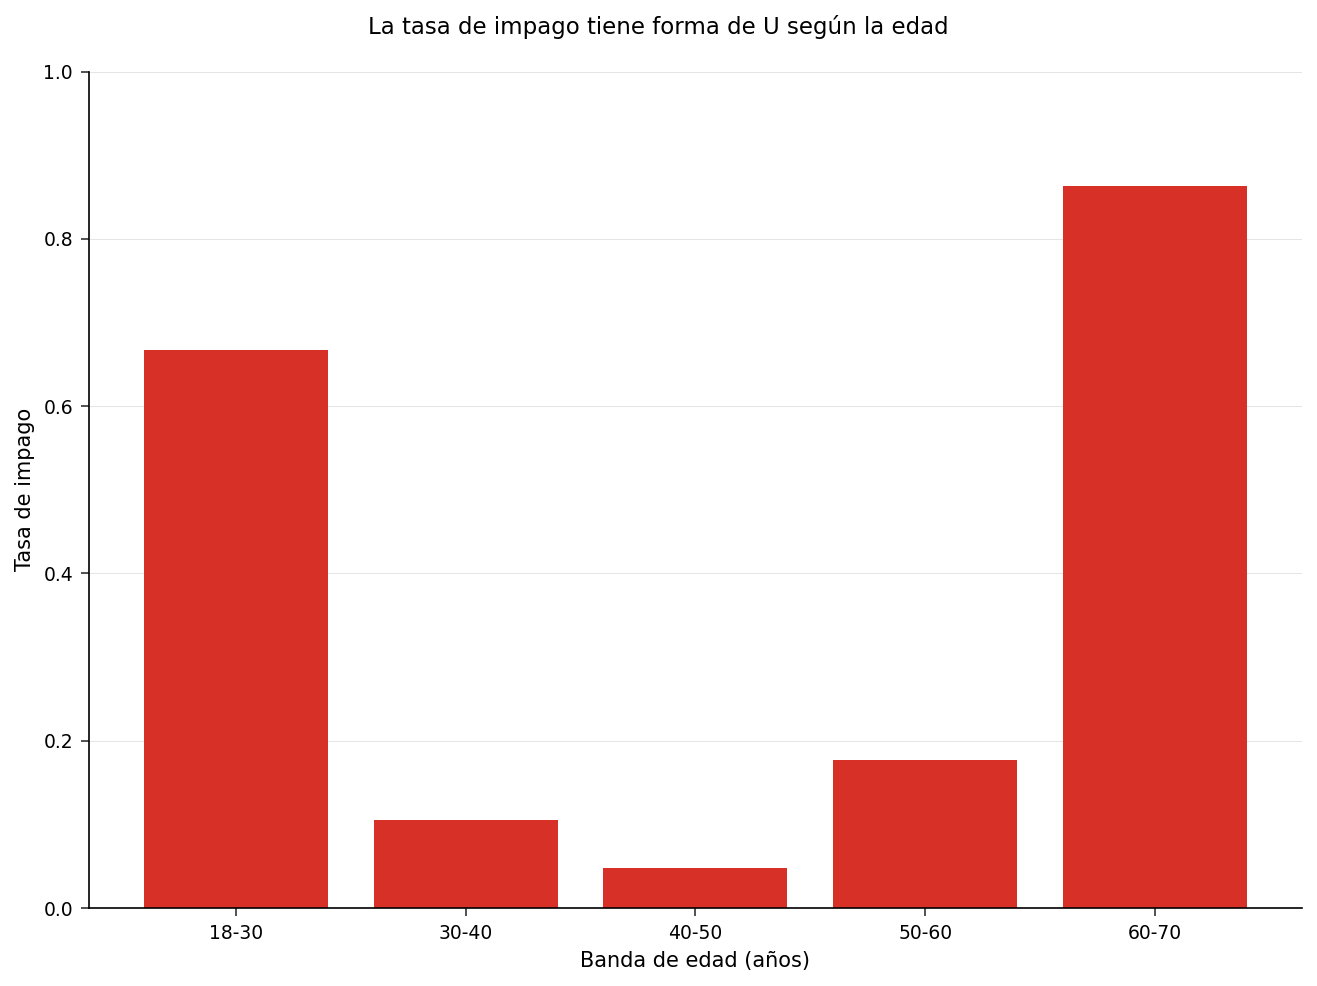

In [4]:
ODS GRAPHICS ON;

PROCEDIMIENTO SGPLOT DATOS=age_rate noautolegend;
   TÍTULO "La tasa de impago tiene forma de U según la edad";
   VBAR age_band / RESPONSE=def_rate fillattrs=(color=cxd73027);
   YAXIS ETIQUETA="Tasa de impago" VALUES=(0 HASTA 1 POR 0.2) grid;
   XAXIS ETIQUETA="Banda de edad (años)";
EJECUTAR;

TÍTULO;
ODS GRAPHICS OFF;

### El riesgo aumenta con el apalancamiento

Las bandas de deuda sobre ingresos tienden al alza —los prestatarios más apalancados incumplen con más frecuencia—, coherente con la spline dominante de DTI en el modelo. Las bandas intermedias son ruidosas con este tamaño de muestra, lo que subraya por qué la spline ajustada es una guía más estable que cualquier corte trazado a mano.


NOTE: ODS Graphics is ON (width=640px, height=480px, format=SVG).
NOTE: PROC SGPLOT data=dti_rate

NOTE: PROC SGPLOT output written to: ./ods_output/sgplot1.svg
NOTE: ODS Graphics is OFF.


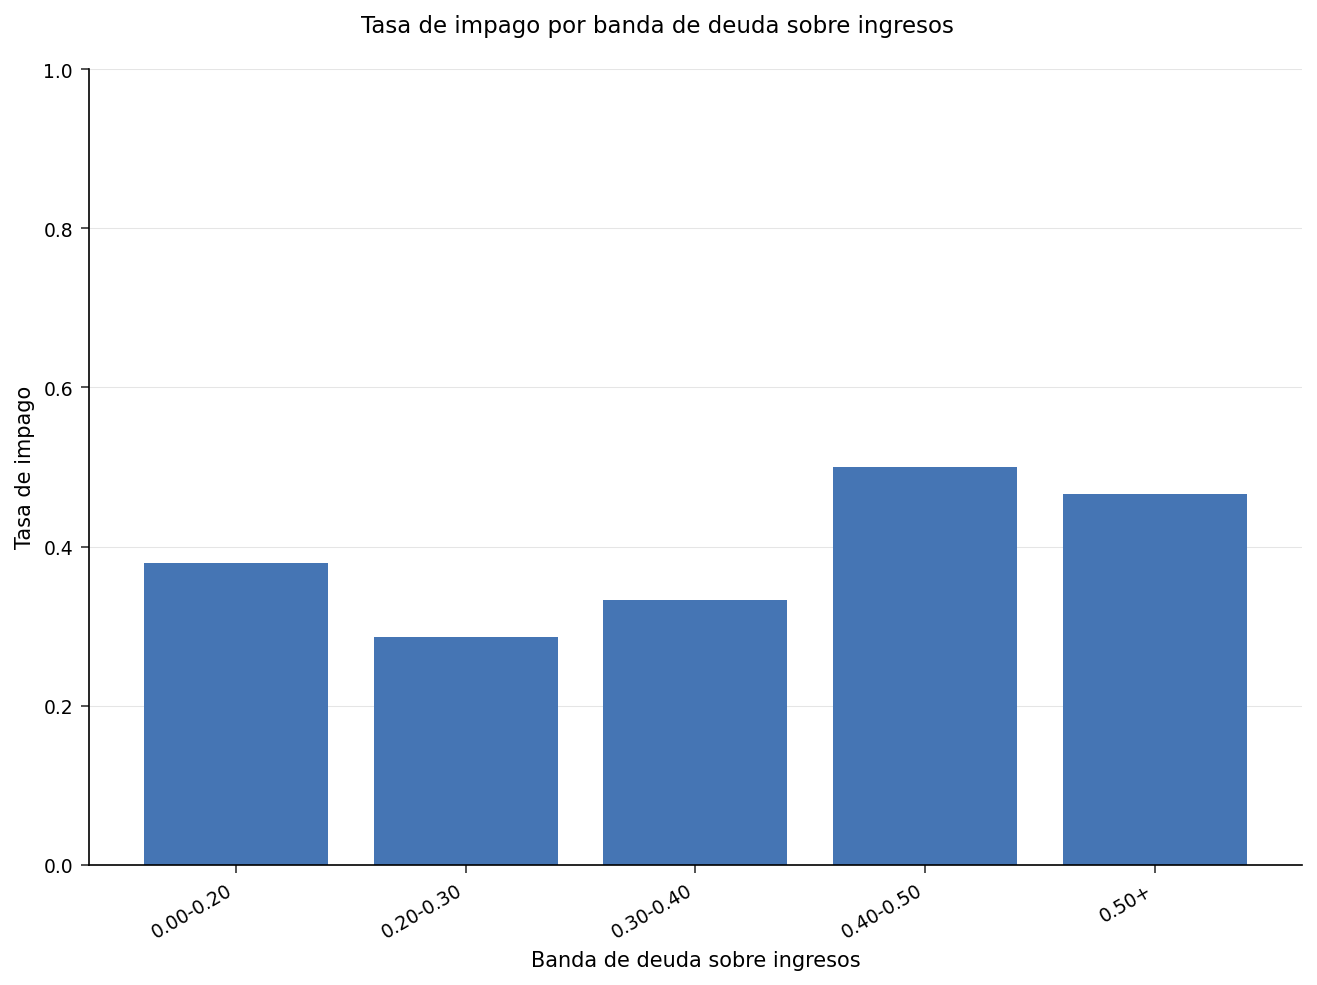

In [5]:
ODS GRAPHICS ON;

PROCEDIMIENTO SGPLOT DATOS=dti_rate noautolegend;
   TÍTULO "Tasa de impago por banda de deuda sobre ingresos";
   VBAR dti_band / RESPONSE=def_rate fillattrs=(color=cx4575b4);
   YAXIS ETIQUETA="Tasa de impago" VALUES=(0 HASTA 1 POR 0.2) grid;
   XAXIS ETIQUETA="Banda de deuda sobre ingresos";
EJECUTAR;

TÍTULO;
ODS GRAPHICS OFF;

## Interpretación de los resultados

`PROC GAM` recuperó la estructura no lineal que incorporamos a la cartera sintética sin ninguna agrupación manual ni términos polinómicos:

- **Buen ajuste global** - el modelo aditivo de splines reduce la devianza de 133.75 a 61.69 (una reducción de 72.06) para un AIC del modelo de 81.69, sobre una cartera con una tasa de impago base del 39 %.
- **El apalancamiento domina** - la función suave de deuda sobre ingresos porta el mayor coeficiente (4.34) de los tres términos, señalando la DTI como el principal impulsor del log-odds ajustado.
- **Curvatura en la edad** - agrupar el resultado bruto confirma una U de manual: 66.7 % de impago en la banda de menores de 30, un valle del 4.8 % en 40-50 y 86.4 % en la banda de 60 y más: la forma que una spline cúbica capta con naturalidad pero que un único término lineal de edad pasaría por alto por completo.
- **Honesto con el ruido** - con 100 préstamos las tasas de deuda sobre ingresos por banda oscilan, que es precisamente el argumento a favor de una estimación suave frente a un corte rígido elegido a mano.

**Por qué esto importa para la banca:** las splines aditivas dan a un equipo de riesgo una forma rápida y automática de detectar dónde una relación es genuinamente no lineal antes de comprometerse con un scorecard de producción. Las funciones suaves ajustadas son directamente interpretables como curvas de riesgo —una prima de edad joven-y-mayor, una rampa de apalancamiento— y la devianza y el AIC cuantifican cuánto aporta esa flexibilidad frente a un modelo lineal plano.